In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"  # must be set before importing jax
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [76]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import numpy as np
from scipy.interpolate import BSpline
from sotodlib.core import AxisManager

In [3]:
# Directories
no_hwpss_dir = Path("/pscratch/sd/b/binguyen/so-sat/preprocessing_exploratory_files")
hwpss_dir = no_hwpss_dir / "processed_with_mask"

# Identifiers
obs_id = "obs_1723712971_satp3_1111111"
ws = "ws1"
f = "f150"

In [60]:
def get_hwpss_model(obs_id, ws, f="f150"):    
    filename = f"aman_{obs_id}_{ws}_{f}.h5"
    
    aman_file = no_hwpss_dir / filename
    aman_hwpss_file = hwpss_dir / filename
    
    obs_no_hwpss = AxisManager.load(str(aman_file))
    obs_hwpss = AxisManager.load(str(aman_hwpss_file))
    
    tod_no_hwpss = obs_no_hwpss.signal
    tod_hwpss = obs_hwpss.signal
    
    hwpss = 1/2 * (tod_no_hwpss - tod_hwpss)
    
    time = obs_hwpss.timestamps - obs_hwpss.timestamps[0]
    hwp_angles = obs_hwpss.hwp_solution.hwp_angle

    pol_angles = np.rad2deg([obs_hwpss.focal_plane.xi, obs_hwpss.focal_plane.eta, obs_hwpss.focal_plane.gamma])
    return time, hwpss, hwp_angles, pol_angles

In [61]:
time, hwpss, hwp_angles, pol_angles = get_hwpss_model(obs_id, ws)

In [62]:
ndet, nsamp = hwpss.shape

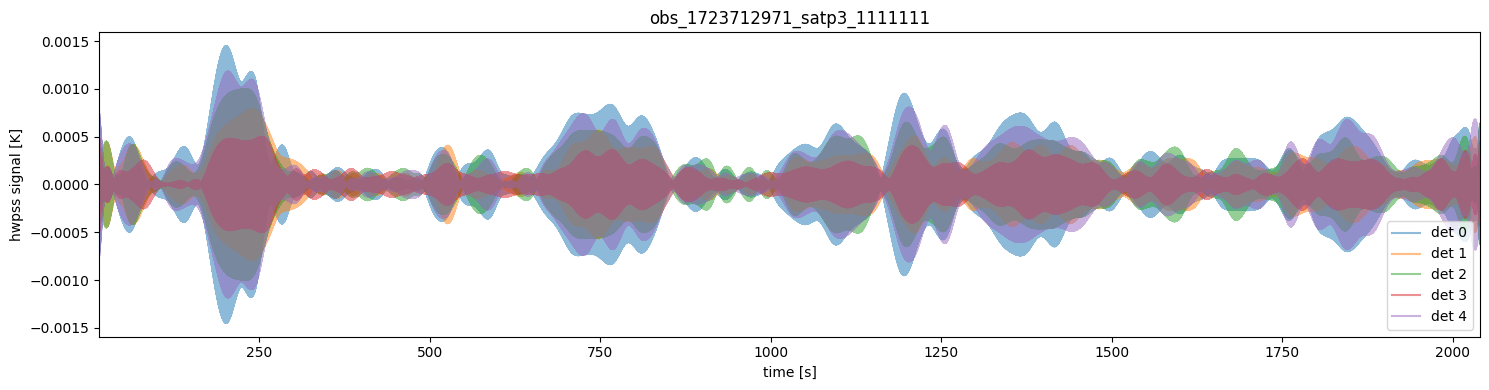

In [9]:
i, f = 3000, nsamp - 1000

plt.figure(figsize=(15,4))
for j in range(5):
    plt.plot(time[i:f], hwpss[j][i:f], alpha=0.5, label=f"det {j}")

plt.xlabel("time [s]")
plt.ylabel("hwpss signal [K]")
plt.legend(loc="lower right")
plt.title(f"{obs_id}")

plt.xlim(time[i], time[f])
plt.tight_layout()
# plt.savefig(f"../figures/{obs_id}_hwpss_model")
plt.show()
plt.close()

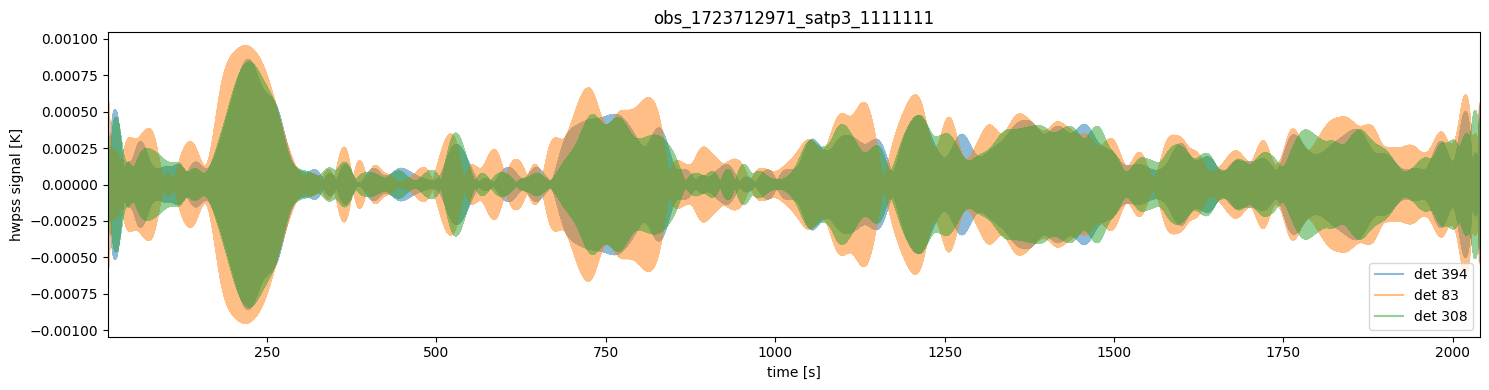

In [10]:
# Randomly select 5 detectors without replacement
dets = np.random.choice(ndet, size=3, replace=False)

plt.figure(figsize=(15, 4))

for det in dets:
    plt.plot(
        time[i:f],
        hwpss[det, i:f],
        alpha=0.5,
        label=f"det {det}"
    )

plt.xlabel("time [s]")
plt.ylabel("hwpss signal [K]")
plt.legend(loc="lower right")
plt.title(obs_id)

plt.xlim(time[i], time[f-1])
plt.tight_layout()
# plt.savefig(f"../figures/{obs_id}_hwpss_model_3random_3.png")
plt.show()
plt.close()

In [11]:
def build_bspline_basis(t, n_knots=100, degree=3):
    """
    Construct cubic B-spline basis matrix.

    Parameters
    ----------
    t : array
        Normalized coordinates in [0, 1]

    n_knots : int
        Number of internal knots

    degree : int
        Spline degree (3 = cubic)

    Returns
    -------
    B : array
        Shape (nsamp, nbasis)
    """

    # -----------------------------------------
    # knot vector
    # -----------------------------------------

    internal_knots = np.linspace(0, 1, n_knots)

    knots = np.concatenate([
        np.repeat(0.0, degree),
        internal_knots,
        np.repeat(1.0, degree)
    ])

    # number of basis functions
    nbasis = len(knots) - degree - 1

    # -----------------------------------------
    # build basis matrix
    # -----------------------------------------

    basis_list = []

    for i in range(nbasis):

        c = np.zeros(nbasis)
        c[i] = 1.0

        spline = BSpline(knots, c, degree, extrapolate=False)

        basis_list.append(spline(t))

    B = np.asarray(basis_list).T

    # replace NaN outside support
    B = np.nan_to_num(B)

    return B

In [12]:
def get_bspline_coeffs(model, n_knots=100, degree=3, harmonics=(4,)):
    if model.ndim == 1:
        model = model[None, :]
    
    nsamps = model.shape[1]
    
    t = np.linspace(0, 1, nsamps)
    
    B = build_bspline_basis(
        t,
        n_knots=n_knots,
        degree=degree,
    )
    
    nbasis = B.shape[1]
    
    cols = []
    
    for h in harmonics:
    
        c = np.cos(h * hwp_angles)
        s = np.sin(h * hwp_angles)
    
        for i in range(nbasis):
            cols.append(B[:, i] * c)
            cols.append(B[:, i] * s)
    
    A = np.column_stack(cols)
    
    # coeffs shape: (nparams, ndets)
    coeffs = np.linalg.lstsq(A, model.T, rcond=None)[0]
    return coeffs

In [13]:
n_knots = max(10, nsamp // 4000)
coeffs = get_bspline_coeffs(hwpss, n_knots)

In [18]:
amp = np.linalg.norm(coeffs, axis=0)  # shape (598,)

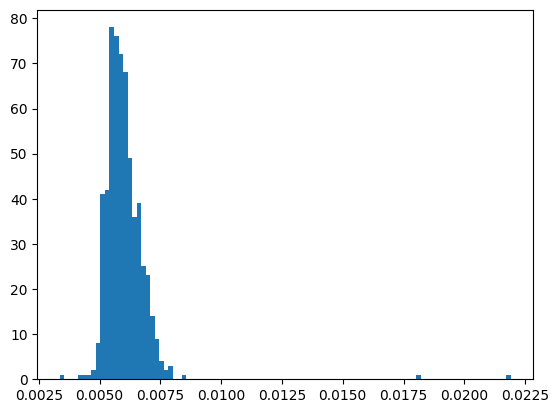

In [22]:
plt.hist(amp, bins=100)

plt.show()

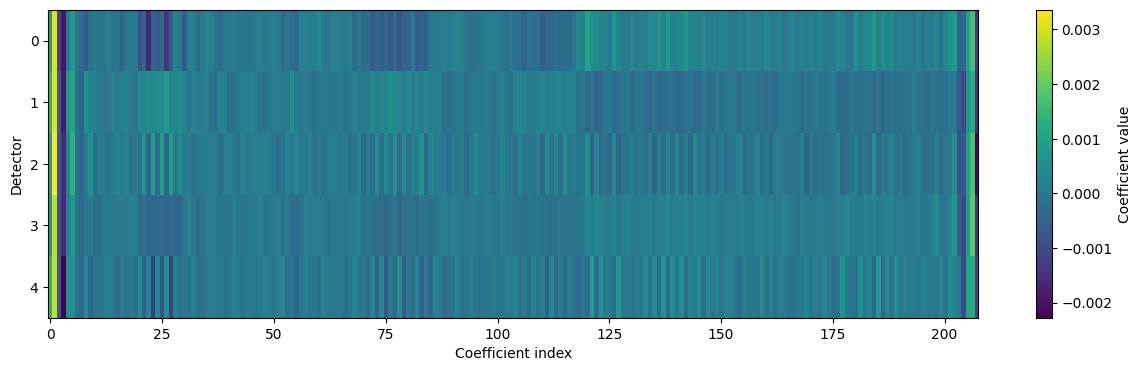

In [37]:
from matplotlib.colors import SymLogNorm

plt.figure(figsize=(15, 4))

plt.imshow(
    coeffs[:, :5].T,
    aspect="auto",
    # norm=SymLogNorm(
    #     linthresh=1e-6,  # linear region around zero
    #     linscale=1,
    #     base=10
    # )
)

plt.colorbar(label="Coefficient value")
plt.ylabel("Detector")
plt.xlabel("Coefficient index")
plt.show()

In [38]:
X = coeffs.T  # (598, 208)

corr = np.corrcoef(X)

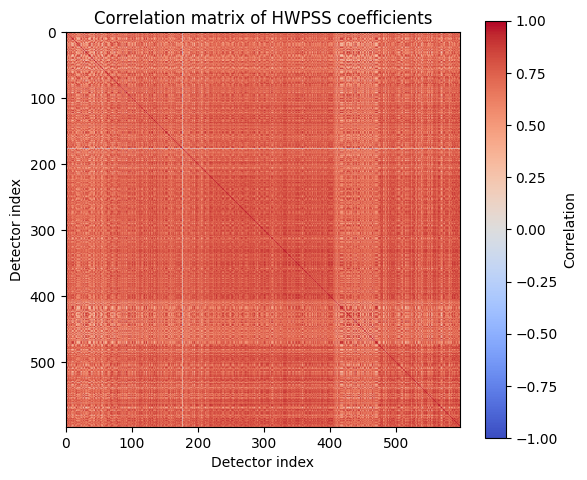

In [42]:
plt.figure(figsize=(6, 5))

plt.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")

plt.colorbar(label="Correlation")

plt.xlabel("Detector index")
plt.ylabel("Detector index")
plt.title("Correlation matrix of HWPSS coefficients")

plt.tight_layout()
plt.savefig(f"{obs_id}_hwpss_corr")
plt.show()

In [46]:
mean_pattern = coeffs.mean(axis=1)

In [47]:
mean_pattern /= np.linalg.norm(mean_pattern)

In [48]:
similarity = []

for d in range(coeffs.shape[1]):
    c = coeffs[:, d]
    c = c / np.linalg.norm(c)
    similarity.append(np.dot(c, mean_pattern))

similarity = np.array(similarity)

In [105]:
from sklearn.decomposition import PCA

X = coeffs.T  # (ndet, nparams)
X_c = X - X.mean(axis=0)  # center

pca = PCA(n_components=4)
scores = pca.fit_transform(X_c)  # (ndet, 4)

pca_scalar = scores[:, 0]  # projection onto dominant mode

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"Cumulative (PC1-4):        {pca.explained_variance_ratio_.cumsum()}")

Variance explained by PC1: 34.6%
Cumulative (PC1-4):        [0.34609582 0.63705493 0.66775785 0.68598723]


In [68]:
# RMS amplitude per detector → shape (ndet,)
rms_per_det = np.sqrt(np.mean(hwpss, axis=1))

# coeffs shape: (nparams, ndet) → norm over params axis
coeff_norm = np.linalg.norm(coeffs, axis=0)  # (ndet,)

In [88]:
xi, eta, gamma = pol_angles

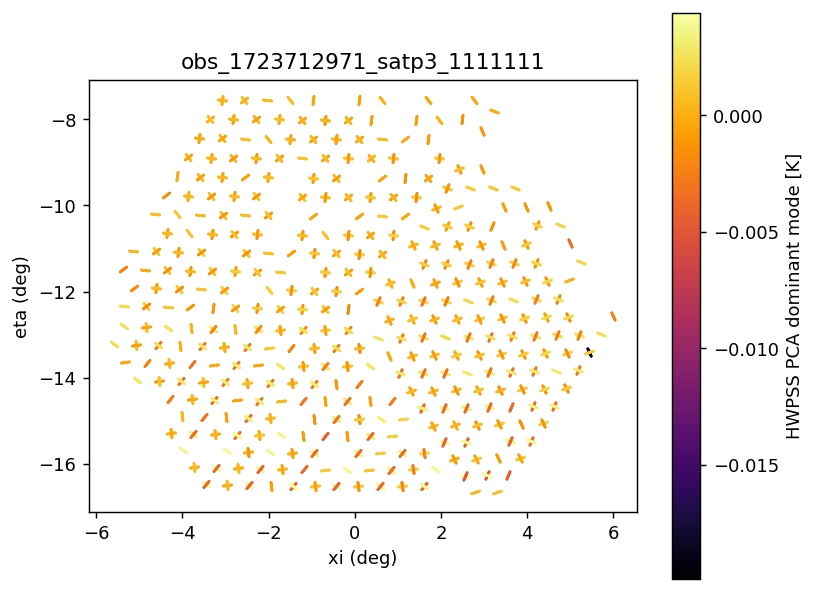

In [107]:
scalar = pca_scalar  # or coeff_norm, pca_scalar

norm = plt.Normalize(vmin=scalar.min(), vmax=scalar.max())
cmap = plt.cm.get_cmap("inferno")

fig, ax = plt.subplots(dpi=130)

for i in range(len(xi)):
    ax.scatter(xi[i], eta[i], marker=(2, 2, gamma[i]), c=[cmap(norm(scalar[i]))], s=20)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="HWPSS PCA dominant mode [K]")

ax.set_aspect("equal")
ax.set_xlabel("xi (deg)")
ax.set_ylabel("eta (deg)")
ax.set_title(f"{obs_id}")
plt.tight_layout()
plt.savefig(f"../figures/{obs_id}_hwpss_focal_plane_pcapca_scalar", dpi=150)
plt.show()